# Interaction Term Model

## Step 0: Box-Cox Power Transformation Check
This step tests a range of power transformations $\lambda$ and identifies the optimal value that best stabilizes variance and improves normality using `scipy.stats.boxcox`.
- If $\lambda \approx 1$: no transformation is needed.
- If $\lambda \approx 0.5$: a square-root transformation is recommended.
- If $\lambda \approx 0$: a log transformation is mathematically optimal.

For BigMart-style target distributions, the optimal $\lambda$ is often close to $0$, so this diagnostic is intentionally kept at the top of the notebook.

=== Box-Cox Power Transformation Diagnostic ===
Target column: Item_Outlet_Sales
Applied positivity shift: 0.000000
Optimal lambda (MLE from scipy.stats.boxcox): 0.346765
Best lambda from tested grid [-2, 2]: 0.350000
Interpretation: use Box-Cox with lambda=0.347 (not a simple special case).


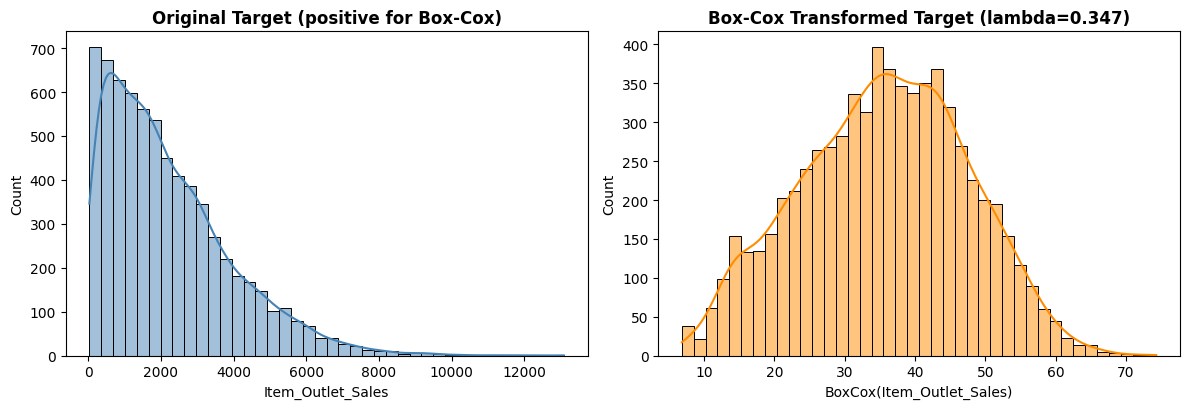

In [ ]:
# 0.0 Box-Cox Power Transformation check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, boxcox_llf

boxcox_target = 'Item_Outlet_Sales'
boxcox_df = pd.read_csv('../data/train_data/train.csv')[[boxcox_target]].dropna().copy()
boxcox_series = boxcox_df[boxcox_target].astype(float)

# Box-Cox requires strictly positive values; shift only when needed.
shift_value = 0.0
if boxcox_series.min() <= 0:
    shift_value = 1.0 - float(boxcox_series.min())

boxcox_input = boxcox_series + shift_value
boxcox_transformed, optimal_lambda = boxcox(boxcox_input.values)

# Explicitly evaluate a lambda grid to show that we are testing a range.
lambda_grid = np.linspace(-2, 2, 161)
llf_values = [boxcox_llf(lmbda, boxcox_input.values) for lmbda in lambda_grid]
grid_best_lambda = float(lambda_grid[int(np.argmax(llf_values))])

if np.isclose(optimal_lambda, 1.0, atol=0.15):
    recommendation = 'lambda is near 1: no transformation is needed.'
elif np.isclose(optimal_lambda, 0.5, atol=0.15):
    recommendation = 'lambda is near 0.5: a square-root transformation is recommended.'
elif np.isclose(optimal_lambda, 0.0, atol=0.15):
    recommendation = 'lambda is near 0: a log transformation is mathematically optimal.'
else:
    recommendation = f'use Box-Cox with lambda={optimal_lambda:.3f} (not a simple special case).'

print('=== Box-Cox Power Transformation Diagnostic ===')
print(f'Target column: {boxcox_target}')
print(f'Applied positivity shift: {shift_value:.6f}')
print(f'Optimal lambda (MLE from scipy.stats.boxcox): {optimal_lambda:.6f}')
print(f'Best lambda from tested grid [-2, 2]: {grid_best_lambda:.6f}')
print(f'Interpretation: {recommendation}')

plt.figure(figsize=(12, 4.2))
plt.subplot(1, 2, 1)
sns.histplot(boxcox_input, kde=True, bins=40, color='steelblue')
plt.title('Original Target (positive for Box-Cox)', fontweight='bold')
plt.xlabel(boxcox_target)

plt.subplot(1, 2, 2)
sns.histplot(boxcox_transformed, kde=True, bins=40, color='darkorange')
plt.title(f'Box-Cox Transformed Target (lambda={optimal_lambda:.3f})', fontweight='bold')
plt.xlabel(f'BoxCox({boxcox_target})')

plt.tight_layout()
plt.show()

Before fitting the full interaction model, we run three diagnostics:
1. Heatmap of independent-variable correlations and surprising-cell checks versus an additive expectation.
2. Grouped boxplots to inspect whether category-to-category steps are inconsistent across sub-groups.
3. Residual analysis from a base model without interactions.

The goal is to create an evidence-based shortlist of potential interaction variables before formal interaction-model fitting.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

import statsmodels.formula.api as smf

# Load training data for interaction screening
screen_df = pd.read_csv('../data/train_data/train.csv')

# Apply Box-Cox transformation to the target variable
optimal_lambda = 0.347
# Ensure target is strictly positive for Box-Cox; Item_Outlet_Sales in this dataset is > 0.
screen_df['Sales_Transformed'] = boxcox(screen_df['Item_Outlet_Sales'], lmbda=optimal_lambda)

target_col = 'Sales_Transformed'
screen_continuous_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
screen_categorical_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
 ]

screen_used_cols = [target_col] + screen_continuous_cols + screen_categorical_cols
screen_df = screen_df[screen_used_cols].copy()

for col in screen_categorical_cols:
    screen_df[col] = screen_df[col].astype('category')

print(f'Rows used for screening: {screen_df.shape[0]}')
print(f'Target variable: {target_col} (Box-Cox, lambda={optimal_lambda})')
print(f'Continuous variables: {screen_continuous_cols}')
print(f'Categorical variables: {screen_categorical_cols}')

Rows used for screening: 6818
Target variable: Sales_Transformed (Box-Cox, lambda=0.347)
Continuous variables: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
Categorical variables: ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


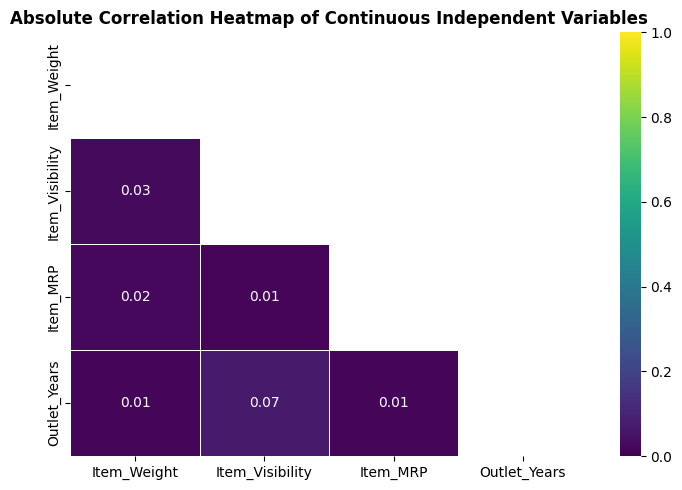

Top continuous-variable pairs by absolute correlation:


,var_1,var_2,corr,abs_corr
0,Item_Visibility,Outlet_Years,0.069742,0.069742
1,Item_Weight,Item_Visibility,-0.026322,0.026322
2,Item_Weight,Item_MRP,0.023157,0.023157
3,Item_MRP,Outlet_Years,-0.014577,0.014577
4,Item_Weight,Outlet_Years,0.012237,0.012237
5,Item_Visibility,Item_MRP,-0.011075,0.011075


In [11]:
# 0.1 Heatmap: absolute correlations are early interaction candidates
corr_matrix = screen_df[screen_continuous_cols].corr()
abs_corr_matrix = corr_matrix.abs()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(abs_corr_matrix, dtype=bool))
sns.heatmap(
    abs_corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    linewidths=0.5
 )
plt.title('Absolute Correlation Heatmap of Continuous Independent Variables', fontweight='bold')
plt.tight_layout()
plt.show()

upper_i, upper_j = np.triu_indices_from(corr_matrix, k=1)
heatmap_candidates_df = pd.DataFrame({
    'var_1': [corr_matrix.index[i] for i in upper_i],
    'var_2': [corr_matrix.columns[j] for j in upper_j],
    'corr': [corr_matrix.iloc[i, j] for i, j in zip(upper_i, upper_j)],
    'abs_corr': [abs_corr_matrix.iloc[i, j] for i, j in zip(upper_i, upper_j)]
})
heatmap_candidates_df = heatmap_candidates_df.sort_values('abs_corr', ascending=False).reset_index(drop=True)

print('Top continuous-variable pairs by absolute correlation:')
display(heatmap_candidates_df.head(10))

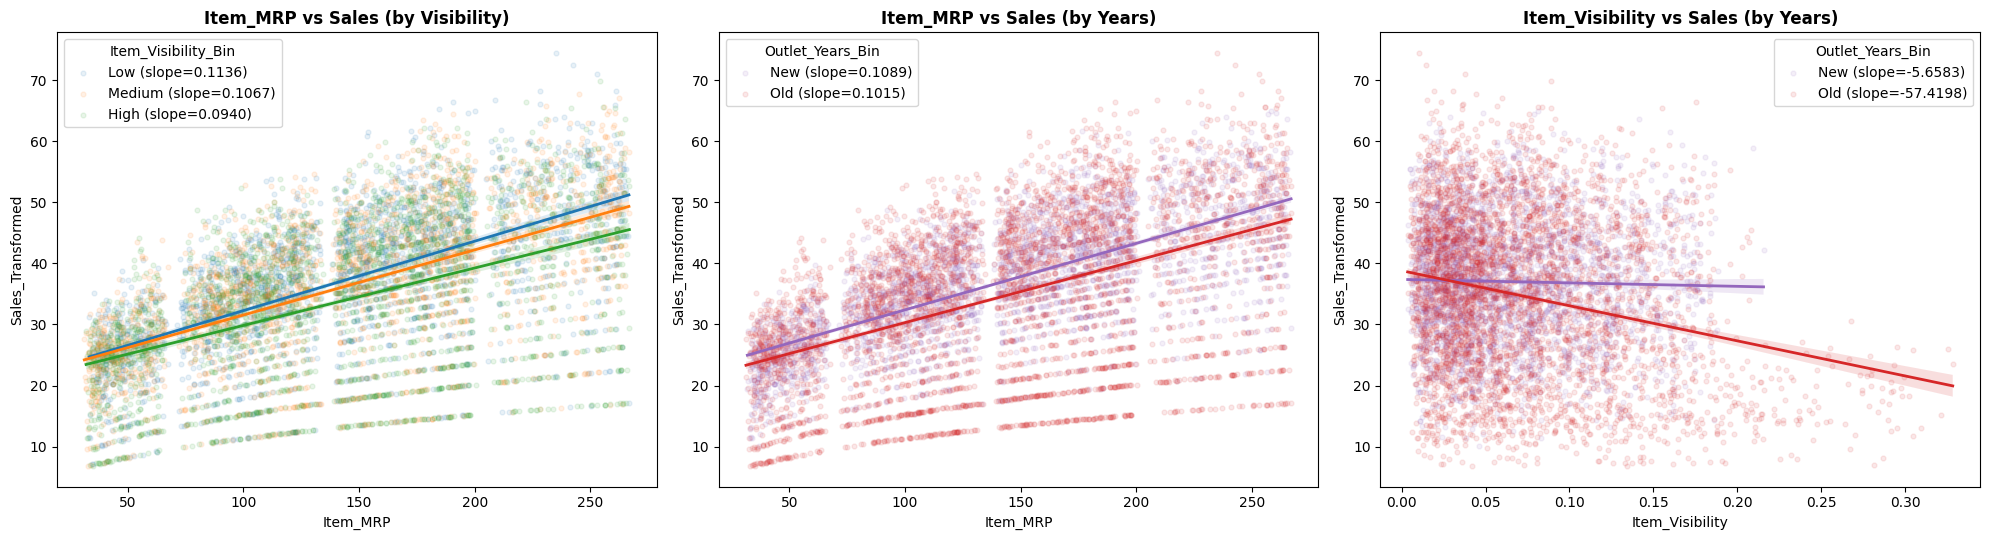

Interaction screening table for all 6 continuous x continuous terms:


,term,Coef.,Std.Err.,t,p_value,decision
0,Item_Visibility:Outlet_Years,-2.691655,0.276494,-9.734947,2.986711e-22,Keep (p < 0.05)
1,Item_Visibility:Item_MRP,-0.159878,0.037676,-4.243482,2.229986e-05,Keep (p < 0.05)
2,Item_Weight:Item_MRP,0.000639,0.000412,1.550662,1.210291e-01,Discard (p >= 0.05)
3,Item_Weight:Outlet_Years,0.000476,0.002997,0.158701,8.739089e-01,Discard (p >= 0.05)
4,Item_MRP:Outlet_Years,-0.000022,0.000222,-0.099488,9.207537e-01,Discard (p >= 0.05)
5,Item_Weight:Item_Visibility,0.040750,0.507123,0.080356,9.359566e-01,Discard (p >= 0.05)


Kept interactions: ['Item_Visibility:Outlet_Years', 'Item_Visibility:Item_MRP']
Discarded interactions: ['Item_Weight:Item_MRP', 'Item_Weight:Outlet_Years', 'Item_MRP:Outlet_Years', 'Item_Weight:Item_Visibility']

VIF for candidate model terms (before centering check):


,term,VIF
0,Item_Visibility,13.437623
1,Item_Visibility:Item_MRP,13.183937
2,Item_Visibility:Outlet_Years,11.262478
3,Item_MRP,10.848124
4,Outlet_Years,9.079513
5,Item_Weight,6.896444



Centering applied because at least one kept interaction had VIF > 10.
Final VIF table (after optional centering):


,term,VIF
0,Item_Visibility_Centered,1.040937
1,Item_Visibility_Centered:Outlet_Years_Centered,1.034727
2,Outlet_Years_Centered,1.005622
3,Item_Visibility_Centered:Item_MRP_Centered,1.001795
4,Item_Weight_Centered,1.001692
5,Item_MRP_Centered,1.001638



AIC/BIC comparison (lower is better):


,model,AIC,BIC,Delta_AIC_vs_Baseline,Delta_BIC_vs_Baseline
0,Baseline (no interactions),50337.224436,50371.361043,0.000000,0.000000
1,Interaction model (final),50227.190985,50274.982235,-110.033451,-96.378808


AIC improved: interactions add explanatory value beyond complexity.
BIC improved: interactions are favored under a stricter complexity penalty.

Final model formula used for interpretation:
Sales_Transformed ~ Item_Weight_Centered + Item_Visibility_Centered + Item_MRP_Centered + Outlet_Years_Centered + Item_Visibility_Centered:Outlet_Years_Centered + Item_Visibility_Centered:Item_MRP_Centered
Centering applied: True


In [12]:
# 0.1d Visualization phase (binning) + statistical phase (6 continuous interaction terms)
from statsmodels.stats.outliers_influence import variance_inflation_factor

phase_df = screen_df[[target_col] + screen_continuous_cols].copy()

# ------------------------------
# Visualization phase: discretization (binning)
# ------------------------------
# Item_Visibility binned into quantile groups for slope comparison against Item_MRP.
phase_df['Item_Visibility_Bin'] = pd.qcut(
    phase_df['Item_Visibility'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
 )

# Outlet_Years binned into New vs Old stores using median split.
years_cutoff = float(phase_df['Outlet_Years'].median())
phase_df['Outlet_Years_Bin'] = np.where(phase_df['Outlet_Years'] >= years_cutoff, 'Old', 'New')
phase_df['Outlet_Years_Bin'] = pd.Categorical(phase_df['Outlet_Years_Bin'], categories=['New', 'Old'], ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

visibility_palette = {'Low': '#1f77b4', 'Medium': '#ff7f0e', 'High': '#2ca02c'}
for vis_bin, grp in phase_df.groupby('Item_Visibility_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_MRP'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_MRP'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_MRP',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=visibility_palette.get(str(vis_bin), None),
        ax=axes[0],
        label=f"{vis_bin} (slope={slope:.4f})"
    )

axes[0].set_title('Item_MRP vs Sales (by Visibility)', fontweight='bold')
axes[0].set_ylabel(f'{target_col}')
axes[0].legend(title='Item_Visibility_Bin')

years_palette = {'New': '#9467bd', 'Old': '#d62728'}
for years_bin, grp in phase_df.groupby('Outlet_Years_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_MRP'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_MRP'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_MRP',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=years_palette.get(str(years_bin), None),
        ax=axes[1],
        label=f"{years_bin} (slope={slope:.4f})"
    )

axes[1].set_title('Item_MRP vs Sales (by Years)', fontweight='bold')
axes[1].set_ylabel(f'{target_col}')
axes[1].legend(title=f'Outlet_Years_Bin')

for years_bin, grp in phase_df.groupby('Outlet_Years_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_Visibility'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_Visibility'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_Visibility',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=years_palette.get(str(years_bin), None),
        ax=axes[2],
        label=f"{years_bin} (slope={slope:.4f})"
    )

axes[2].set_title('Item_Visibility vs Sales (by Years)', fontweight='bold')
axes[2].set_ylabel(f'{target_col}')
axes[2].legend(title=f'Outlet_Years_Bin')

plt.tight_layout()
plt.show()

# ------------------------------
# Statistical phase: one OLS with all 6 continuous x continuous interactions
# ------------------------------
interaction_pairs = list(itertools.combinations(screen_continuous_cols, 2))
interaction_terms = [f'{a}:{b}' for a, b in interaction_pairs]
main_formula_part = ' + '.join(screen_continuous_cols)
interaction_formula_part = ' + '.join(interaction_terms)

six_interaction_formula = f"{target_col} ~ {main_formula_part} + {interaction_formula_part}"
six_interaction_model = smf.ols(six_interaction_formula, data=phase_df).fit()

coef_table = (
    six_interaction_model.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'term', 'P>|t|': 'p_value'})
)

interaction_results_df = (
    coef_table[coef_table['term'].isin(interaction_terms)][['term', 'Coef.', 'Std.Err.', 't', 'p_value']]
    .sort_values('p_value')
    .reset_index(drop=True)
)

interaction_results_df['decision'] = np.where(
    interaction_results_df['p_value'] < 0.05,
    'Keep (p < 0.05)',
    'Discard (p >= 0.05)'
)

print('Interaction screening table for all 6 continuous x continuous terms:')
display(interaction_results_df)

kept_interactions = interaction_results_df.loc[
    interaction_results_df['p_value'] < 0.05,
    'term'
].tolist()

discarded_interactions = interaction_results_df.loc[
    interaction_results_df['p_value'] >= 0.05,
    'term'
].tolist()

print(f'Kept interactions: {kept_interactions if kept_interactions else "None"}')
print(f'Discarded interactions: {discarded_interactions if discarded_interactions else "None"}')

# Build candidate model with only significant interactions (if any), while retaining main effects.
candidate_formula = f"{target_col} ~ {main_formula_part}"
if kept_interactions:
    candidate_formula += ' + ' + ' + '.join(kept_interactions)

candidate_model = smf.ols(candidate_formula, data=phase_df).fit()

def compute_vif_table(model):
    exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names).copy()
    if 'Intercept' in exog.columns:
        exog = exog.drop(columns=['Intercept'])

    vif_rows = []
    for idx, col_name in enumerate(exog.columns):
        vif_rows.append({
            'term': col_name,
            'VIF': float(variance_inflation_factor(exog.values, idx))
        })

    vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

initial_vif_df = compute_vif_table(candidate_model)
print('\nVIF for candidate model terms (before centering check):')
display(initial_vif_df)

high_vif_terms = initial_vif_df.loc[initial_vif_df['VIF'] > 10, 'term'].tolist()
high_vif_interactions = [term for term in high_vif_terms if ':' in term and term in kept_interactions]

final_model = candidate_model
final_formula = candidate_formula
centering_applied = False

# Fix for high VIF in significant continuous interactions: mean-center variables before creating products.
if high_vif_interactions:
    centered_map = {}
    for col in screen_continuous_cols:
        centered_col = f'{col}_Centered'
        phase_df[centered_col] = phase_df[col] - phase_df[col].mean()
        centered_map[col] = centered_col

    centered_main = [centered_map[c] for c in screen_continuous_cols]
    centered_kept_interactions = []
    for term in kept_interactions:
        left, right = term.split(':')
        centered_kept_interactions.append(f"{centered_map[left]}:{centered_map[right]}")

    final_formula = f"{target_col} ~ " + ' + '.join(centered_main)
    if centered_kept_interactions:
        final_formula += ' + ' + ' + '.join(centered_kept_interactions)

    final_model = smf.ols(final_formula, data=phase_df).fit()
    centering_applied = True
    print('\nCentering applied because at least one kept interaction had VIF > 10.')
else:
    print('\nNo centering needed based on VIF threshold > 10 for kept interactions.')

final_vif_df = compute_vif_table(final_model)
print('Final VIF table (after optional centering):')
display(final_vif_df)

# ------------------------------
# Model comparison: interaction model vs no-interaction baseline
# ------------------------------
baseline_formula = f"{target_col} ~ {main_formula_part}"
baseline_model = smf.ols(baseline_formula, data=phase_df).fit()

comparison_df = pd.DataFrame([
    {
        'model': 'Baseline (no interactions)',
        'AIC': baseline_model.aic,
        'BIC': baseline_model.bic
    },
    {
        'model': 'Interaction model (final)',
        'AIC': final_model.aic,
        'BIC': final_model.bic
    }
])

comparison_df['Delta_AIC_vs_Baseline'] = comparison_df['AIC'] - baseline_model.aic
comparison_df['Delta_BIC_vs_Baseline'] = comparison_df['BIC'] - baseline_model.bic

print('\nAIC/BIC comparison (lower is better):')
display(comparison_df)

if final_model.aic < baseline_model.aic:
    print('AIC improved: interactions add explanatory value beyond complexity.')
else:
    print('AIC did not improve: apply parsimony and consider removing interactions.')

if final_model.bic < baseline_model.bic:
    print('BIC improved: interactions are favored under a stricter complexity penalty.')
else:
    print('BIC did not improve: stricter parsimony favors the simpler model.')

print('\nFinal model formula used for interpretation:')
print(final_formula)
print(f'Centering applied: {centering_applied}')

In [12]:
# 0.1b Surprising cells: observed sales vs additive expectation for categorical pairs
def surprising_cells_for_pair(data, cat_a, cat_b, target, min_count=30):
    tmp = data[[cat_a, cat_b, target]].dropna().copy()
    grand_mean = tmp[target].mean()

    effect_a = (tmp.groupby(cat_a, observed=True)[target].mean() - grand_mean).to_dict()
    effect_b = (tmp.groupby(cat_b, observed=True)[target].mean() - grand_mean).to_dict()

    cell_stats = (
        tmp.groupby([cat_a, cat_b], observed=True)[target]
        .agg(mean_sales='mean', n='size')
        .reset_index()
    )
    cell_stats = cell_stats[cell_stats['n'] >= min_count].copy()

    if cell_stats.empty:
        return pd.DataFrame()

    expected_a = cell_stats[cat_a].astype(str).map(effect_a).astype(float)
    expected_b = cell_stats[cat_b].astype(str).map(effect_b).astype(float)

    cell_stats['additive_expected'] = grand_mean + expected_a + expected_b
    cell_stats['interaction_gap'] = cell_stats['mean_sales'] - cell_stats['additive_expected']
    cell_stats['abs_gap'] = cell_stats['interaction_gap'].abs()
    cell_stats['cat_a'] = cat_a
    cell_stats['cat_b'] = cat_b
    cell_stats = cell_stats.rename(columns={cat_a: 'level_a', cat_b: 'level_b'})

    return cell_stats[[
        'cat_a',
        'cat_b',
        'level_a',
        'level_b',
        'n',
        'mean_sales',
        'additive_expected',
        'interaction_gap',
        'abs_gap'
    ]]

surprising_frames = []
for cat_a, cat_b in itertools.combinations(screen_categorical_cols, 2):
    pair_cells = surprising_cells_for_pair(screen_df, cat_a, cat_b, target_col, min_count=30)
    if not pair_cells.empty:
        surprising_frames.append(pair_cells)

if surprising_frames:
    surprising_cells_df = pd.concat(surprising_frames, ignore_index=True)
    surprising_cells_df = surprising_cells_df.sort_values('abs_gap', ascending=False).reset_index(drop=True)

    surprising_pair_summary = (
        surprising_cells_df.groupby(['cat_a', 'cat_b'], as_index=False)
        .agg(
            max_abs_gap=('abs_gap', 'max'),
            mean_abs_gap=('abs_gap', 'mean'),
            n_cells=('abs_gap', 'size')
        )
        .sort_values('mean_abs_gap', ascending=False)
        .reset_index(drop=True)
    )

    print('Most surprising cells (largest deviations from additive expectation):')
    display(surprising_cells_df.head(15))

    print('Categorical pairs ranked by surprising-cell signal (mean_abs_gap):')
    display(surprising_pair_summary.head(10))
else:
    surprising_cells_df = pd.DataFrame(
        columns=['cat_a', 'cat_b', 'level_a', 'level_b', 'n', 'mean_sales', 'additive_expected', 'interaction_gap', 'abs_gap']
    )
    surprising_pair_summary = pd.DataFrame(columns=['cat_a', 'cat_b', 'max_abs_gap', 'mean_abs_gap', 'n_cells'])
    print('No categorical pairs had enough observations for surprising-cell analysis.')

Most surprising cells (largest deviations from additive expectation):


,cat_a,cat_b,level_a,level_b,n,mean_sales,additive_expected,interaction_gap,abs_gap
0,Outlet_Size,Outlet_Location_Type,Unknown,Tier 3,446,17.706916,32.766761,-15.059845,15.059845
1,Outlet_Size,Outlet_Type,Medium,Supermarket Type3,761,44.829174,48.649720,-3.820546,3.820546
2,Outlet_Size,Outlet_Type,Medium,Supermarket Type2,752,35.495273,39.315819,-3.820546,3.820546
3,Outlet_Size,Outlet_Type,Medium,Supermarket Type1,720,37.807698,41.321640,-3.513942,3.513942
4,Outlet_Size,Outlet_Type,Unknown,Grocery Store,446,17.706916,14.728399,2.978517,2.978517
5,Outlet_Size,Outlet_Location_Type,Small,Tier 2,750,38.252677,35.305107,2.947571,2.947571
6,Outlet_Size,Outlet_Location_Type,Unknown,Tier 2,1489,37.117563,34.540075,2.577489,2.577489
7,Outlet_Size,Outlet_Type,Unknown,Supermarket Type1,1489,37.117563,34.543375,2.574188,2.574188
8,Item_Fat_Content,Item_Type,Low Fat,Breakfast,31,37.271447,34.725259,2.546189,2.546189
9,Outlet_Location_Type,Outlet_Type,Tier 1,Supermarket Type1,1463,37.535043,35.060163,2.474880,2.474880


Categorical pairs ranked by surprising-cell signal (mean_abs_gap):


,cat_a,cat_b,max_abs_gap,mean_abs_gap,n_cells
0,Outlet_Size,Outlet_Location_Type,15.059845,3.268809,7
1,Outlet_Size,Outlet_Type,3.820546,2.904175,8
2,Outlet_Location_Type,Outlet_Type,2.474880,1.045982,7
3,Item_Type,Outlet_Size,2.457788,0.662015,51
4,Item_Fat_Content,Item_Type,2.546189,0.635123,26
5,Item_Type,Outlet_Type,1.649787,0.552756,45
6,Item_Type,Outlet_Location_Type,1.448155,0.453845,42
7,Item_Fat_Content,Outlet_Type,0.796170,0.330549,12
8,Item_Fat_Content,Outlet_Location_Type,0.524223,0.326910,9
9,Item_Fat_Content,Outlet_Size,0.589789,0.195928,12


In [13]:
# 0.1c Formal Two-Way ANOVA for top surprising categorical-pair candidates
# Use top pairs ranked by mean_abs_gap and test each interaction term with exact F and p-values.
from statsmodels.stats.anova import anova_lm
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

if surprising_pair_summary.empty:
    anova_pair_results_df = pd.DataFrame(
        columns=['rank_by_mean_abs_gap', 'cat_a', 'cat_b', 'mean_abs_gap', 'n_cells', 'interaction_term', 'F_stat', 'p_value']
    )
    print('No categorical pairs available for formal Two-Way ANOVA interaction testing.')
else:
    top_pair_candidates = surprising_pair_summary.copy().reset_index(drop=True)

    anova_pair_results = []
    for rank, row in top_pair_candidates.iterrows():
        cat_a = row['cat_a']
        cat_b = row['cat_b']
        formula = f"{target_col} ~ C({cat_a}) * C({cat_b})"

        pair_df = screen_df[[target_col, cat_a, cat_b]].dropna().copy()

        # Skip degenerate cases where a factor has only one level after NA filtering.
        if pair_df[cat_a].nunique() < 2 or pair_df[cat_b].nunique() < 2:
            anova_pair_results.append({
                'rank_by_mean_abs_gap': int(rank + 1),
                'cat_a': cat_a,
                'cat_b': cat_b,
                'mean_abs_gap': float(row['mean_abs_gap']),
                'n_cells': int(row['n_cells']),
                'interaction_term': f"C({cat_a}):C({cat_b})",
                'F_stat': np.nan,
                'p_value': np.nan
            })
            continue

        model = smf.ols(formula, data=pair_df).fit()
        
        # Suppress "covariance of constraints does not have full rank" warnings 
        # which occur when certain level combinations are missing (rank deficiency).
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore',
                category=ValueWarning,
                message='.*covariance of constraints does not have full rank.*'
            )
            anova_tbl = anova_lm(model, typ=2)

        interaction_term = f"C({cat_a}):C({cat_b})"
        if interaction_term in anova_tbl.index:
            f_val = float(anova_tbl.loc[interaction_term, 'F'])
            p_val = float(anova_tbl.loc[interaction_term, 'PR(>F)'])
        else:
            f_val = np.nan
            p_val = np.nan

        anova_pair_results.append({
            'rank_by_mean_abs_gap': int(rank + 1),
            'cat_a': cat_a,
            'cat_b': cat_b,
            'mean_abs_gap': float(row['mean_abs_gap']),
            'n_cells': int(row['n_cells']),
            'interaction_term': interaction_term,
            'F_stat': f_val,
            'p_value': p_val
        })

    anova_pair_results_df = pd.DataFrame(anova_pair_results).sort_values(
        'rank_by_mean_abs_gap'
    ).reset_index(drop=True)

    print(f'Formal Two-Way ANOVA interaction tests for top {len(anova_pair_results_df)} categorical-pair candidates:')
    display(anova_pair_results_df.sort_values('p_value'))

    significant_interactions_df = anova_pair_results_df[anova_pair_results_df['p_value'] < 0.05].copy()
    if significant_interactions_df.empty:
        print('No candidate pair has interaction p-value < 0.05 in this Two-Way ANOVA screening step.')
    else:
        print('Pairs with statistically significant interaction terms (p-value < 0.05):')
        display(significant_interactions_df)

Formal Two-Way ANOVA interaction tests for top 10 categorical-pair candidates:


,rank_by_mean_abs_gap,cat_a,cat_b,mean_abs_gap,n_cells,interaction_term,F_stat,p_value
2,3,Outlet_Location_Type,Outlet_Type,1.045982,7,C(Outlet_Location_Type):C(Outlet_Type),1.751162,0.173650
8,9,Item_Fat_Content,Outlet_Location_Type,0.326910,9,C(Item_Fat_Content):C(Outlet_Location_Type),1.461713,0.211011
4,5,Item_Fat_Content,Item_Type,0.635123,26,C(Item_Fat_Content):C(Item_Type),1.231518,0.296480
7,8,Item_Fat_Content,Outlet_Type,0.330549,12,C(Item_Fat_Content):C(Outlet_Type),0.904929,0.490079
1,2,Outlet_Size,Outlet_Type,2.904175,8,C(Outlet_Size):C(Outlet_Type),0.763142,0.549106
9,10,Item_Fat_Content,Outlet_Size,0.195928,12,C(Item_Fat_Content):C(Outlet_Size),0.368357,0.899363
0,1,Outlet_Size,Outlet_Location_Type,3.268809,7,C(Outlet_Size):C(Outlet_Location_Type),0.169437,0.917058
5,6,Item_Type,Outlet_Type,0.552756,45,C(Item_Type):C(Outlet_Type),0.635701,0.972640
3,4,Item_Type,Outlet_Size,0.662015,51,C(Item_Type):C(Outlet_Size),0.624083,0.977050
6,7,Item_Type,Outlet_Location_Type,0.453845,42,C(Item_Type):C(Outlet_Location_Type),0.519231,0.985945


No candidate pair has interaction p-value < 0.05 in this Two-Way ANOVA screening step.


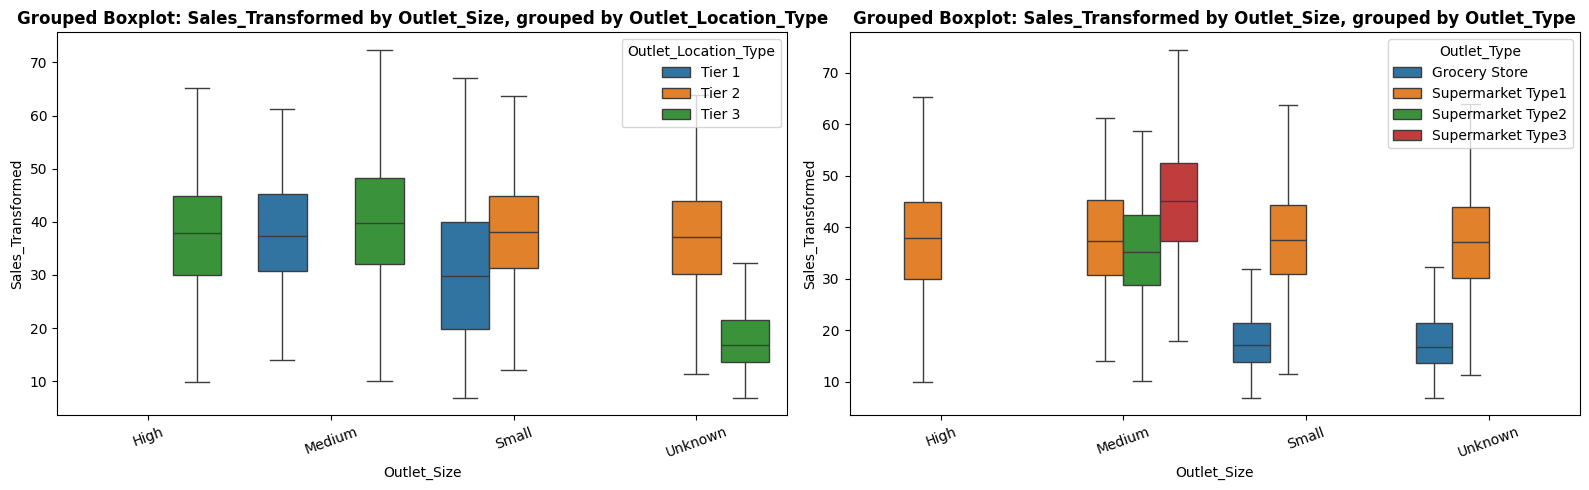

Grouped boxplot inconsistency scores (higher -> stronger interaction signal):


,x_var,hue_var,step_inconsistency_score
1,Outlet_Size,Outlet_Type,0.049094
0,Outlet_Size,Outlet_Location_Type,NaN


In [14]:
# 0.2 Grouped boxplots: inconsistent category steps across sub-groups suggest interaction
def step_inconsistency_score(data, x, hue, target):
    med = data.groupby([x, hue], observed=True)[target].median().unstack(hue)
    med = med.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if med.shape[0] < 2 or med.shape[1] < 2:
        return np.nan

    step_changes = med.diff().iloc[1:]
    if step_changes.empty:
        return np.nan

    row_stds = []
    for _, row in step_changes.iterrows():
        valid_values = row.dropna().values
        if valid_values.size >= 2:
            row_stds.append(float(np.std(valid_values, ddof=0)))

    if not row_stds:
        return np.nan

    return float(np.mean(row_stds))

category_sizes = {c: int(screen_df[c].nunique()) for c in screen_categorical_cols}

if surprising_pair_summary.empty:
    selected_boxplot_pairs = [
        ('Outlet_Size', 'Outlet_Type'),
        ('Outlet_Location_Type', 'Outlet_Type')
    ]
else:
    eligible_pairs = surprising_pair_summary[
        surprising_pair_summary['cat_a'].map(category_sizes).le(6)
        & surprising_pair_summary['cat_b'].map(category_sizes).le(6)
    ].copy()

    if eligible_pairs.empty:
        selected_boxplot_pairs = [
            ('Outlet_Size', 'Outlet_Type'),
            ('Outlet_Location_Type', 'Outlet_Type')
        ]
    else:
        selected_boxplot_pairs = list(
            eligible_pairs[['cat_a', 'cat_b']].head(2).itertuples(index=False, name=None)
        )

fig, axes = plt.subplots(1, len(selected_boxplot_pairs), figsize=(8 * len(selected_boxplot_pairs), 5))
if len(selected_boxplot_pairs) == 1:
    axes = [axes]

grouped_boxplot_scores = []
for ax, (x_var, hue_var) in zip(axes, selected_boxplot_pairs):
    sns.boxplot(
        data=screen_df,
        x=x_var,
        y=target_col,
        hue=hue_var,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'Grouped Boxplot: {target_col} by {x_var}, grouped by {hue_var}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    grouped_boxplot_scores.append({
        'x_var': x_var,
        'hue_var': hue_var,
        'step_inconsistency_score': step_inconsistency_score(screen_df, x_var, hue_var, target_col)
    })

plt.tight_layout()
plt.show()

grouped_boxplot_scores_df = pd.DataFrame(grouped_boxplot_scores).sort_values(
    'step_inconsistency_score',
    ascending=False
 )

print('Grouped boxplot inconsistency scores (higher -> stronger interaction signal):')
display(grouped_boxplot_scores_df)

Base model formula: Item_Outlet_Sales ~ Item_Weight + Item_Visibility + Item_MRP + Outlet_Years + C(Item_Fat_Content) + C(Item_Type) + C(Outlet_Size) + C(Outlet_Location_Type) + C(Outlet_Type)
Base model R-squared: 0.5593
Base model Adj. R-squared: 0.5575


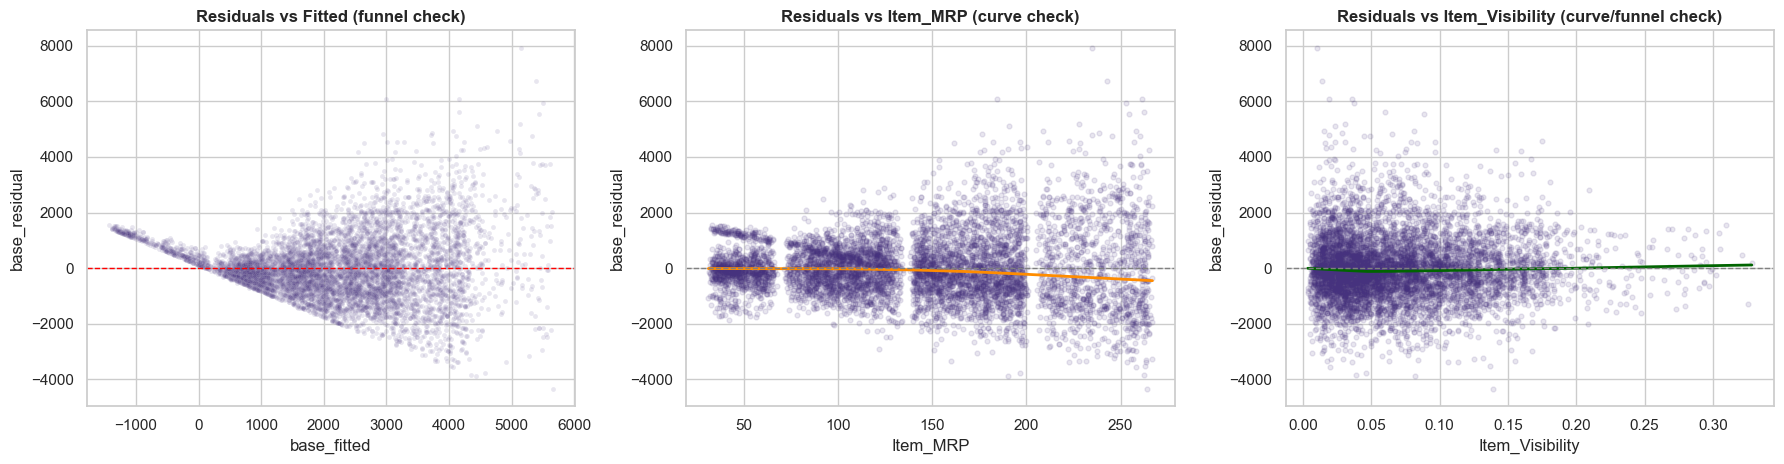

Correlation(abs(residual), fitted): 0.4131
Top continuous x continuous residual interaction signals:


,var_1,var_2,pair,resid_corr_with_product,abs_score
3,Item_Visibility,Item_MRP,Item_Visibility : Item_MRP,-0.034355,0.034355
5,Item_MRP,Outlet_Years,Item_MRP : Outlet_Years,0.011813,0.011813
0,Item_Weight,Item_Visibility,Item_Weight : Item_Visibility,-0.002658,0.002658
1,Item_Weight,Item_MRP,Item_Weight : Item_MRP,0.001945,0.001945
4,Item_Visibility,Outlet_Years,Item_Visibility : Outlet_Years,-0.001698,0.001698
2,Item_Weight,Outlet_Years,Item_Weight : Outlet_Years,0.001105,0.001105


Top continuous x categorical residual interaction signals:


,continuous_var,categorical_var,pair,slope_spread,abs_score
6,Item_Visibility,Item_Type,Item_Visibility : Item_Type,3634.763639,3634.763639
9,Item_Visibility,Outlet_Type,Item_Visibility : Outlet_Type,1792.303043,1792.303043
8,Item_Visibility,Outlet_Location_Type,Item_Visibility : Outlet_Location_Type,1025.818046,1025.818046
7,Item_Visibility,Outlet_Size,Item_Visibility : Outlet_Size,906.861077,906.861077
5,Item_Visibility,Item_Fat_Content,Item_Visibility : Item_Fat_Content,593.379002,593.379002
1,Item_Weight,Item_Type,Item_Weight : Item_Type,86.339138,86.339138
16,Outlet_Years,Item_Type,Outlet_Years : Item_Type,52.680641,52.680641
14,Item_MRP,Outlet_Type,Item_MRP : Outlet_Type,23.083024,23.083024
3,Item_Weight,Outlet_Location_Type,Item_Weight : Outlet_Location_Type,15.157753,15.157753
4,Item_Weight,Outlet_Type,Item_Weight : Outlet_Type,10.696536,10.696536


In [17]:
# 0.3 Residual analysis from a base model without interactions
base_terms = screen_continuous_cols + [f'C({c})' for c in screen_categorical_cols]
base_formula = f"{target_col} ~ " + ' + '.join(base_terms)
base_model = smf.ols(base_formula, data=screen_df).fit()

screen_df = screen_df.copy()
screen_df['base_fitted'] = base_model.fittedvalues
screen_df['base_residual'] = base_model.resid

print(f'Base model formula: {base_formula}')
print(f'Base model R-squared: {base_model.rsquared:.4f}')
print(f'Base model Adj. R-squared: {base_model.rsquared_adj:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.scatterplot(
    data=screen_df,
    x='base_fitted',
    y='base_residual',
    alpha=0.12,
    s=12,
    ax=axes[0]
 )
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted (funnel check)', fontweight='bold')

sns.regplot(
    data=screen_df,
    x='Item_MRP',
    y='base_residual',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=axes[1]
 )
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Residuals vs Item_MRP (curve check)', fontweight='bold')

sns.regplot(
    data=screen_df,
    x='Item_Visibility',
    y='base_residual',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    ax=axes[2]
 )
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Residuals vs Item_Visibility (curve/funnel check)', fontweight='bold')

plt.tight_layout()
plt.show()

funnel_corr = np.corrcoef(screen_df['base_fitted'], np.abs(screen_df['base_residual']))[0, 1]
print(f'Correlation(abs(residual), fitted): {funnel_corr:.4f}')

cont_cont_scores = []
for var_1, var_2 in itertools.combinations(screen_continuous_cols, 2):
    product_term = screen_df[var_1] * screen_df[var_2]
    corr_with_resid = np.corrcoef(screen_df['base_residual'], product_term)[0, 1]
    cont_cont_scores.append({
        'var_1': var_1,
        'var_2': var_2,
        'pair': f'{var_1} : {var_2}',
        'resid_corr_with_product': corr_with_resid,
        'abs_score': abs(corr_with_resid)
    })

cont_cont_resid_scores_df = pd.DataFrame(cont_cont_scores).sort_values('abs_score', ascending=False)

cont_cat_scores = []
for cont_var in screen_continuous_cols:
    for cat_var in screen_categorical_cols:
        slopes = []
        for _, group_df in screen_df.groupby(cat_var, observed=True):
            if group_df.shape[0] >= 40 and group_df[cont_var].nunique() > 2:
                slope = np.polyfit(group_df[cont_var], group_df['base_residual'], 1)[0]
                slopes.append(slope)
        if len(slopes) >= 2:
            slope_spread = float(np.max(slopes) - np.min(slopes))
            cont_cat_scores.append({
                'continuous_var': cont_var,
                'categorical_var': cat_var,
                'pair': f'{cont_var} : {cat_var}',
                'slope_spread': slope_spread,
                'abs_score': abs(slope_spread)
            })

if cont_cat_scores:
    cont_cat_resid_scores_df = pd.DataFrame(cont_cat_scores).sort_values('abs_score', ascending=False)
else:
    cont_cat_resid_scores_df = pd.DataFrame(
        columns=['continuous_var', 'categorical_var', 'pair', 'slope_spread', 'abs_score']
    )

print('Top continuous x continuous residual interaction signals:')
display(cont_cont_resid_scores_df.head(10))

print('Top continuous x categorical residual interaction signals:')
display(cont_cat_resid_scores_df.head(10))

In [18]:
# 0.4 Consolidated report: potential interaction variables from all diagnostics
def canonical_pair_name(var_a, var_b):
    return ' x '.join(sorted([var_a, var_b]))

evidence_rows = []

if not heatmap_candidates_df.empty:
    heatmap_cutoff = max(0.15, float(heatmap_candidates_df['abs_corr'].quantile(0.75)))
    for row in heatmap_candidates_df[heatmap_candidates_df['abs_corr'] >= heatmap_cutoff].itertuples(index=False):
        evidence_rows.append({
            'pair': canonical_pair_name(row.var_1, row.var_2),
            'source': 'Heatmap correlation',
            'score': float(row.abs_corr),
            'detail': f"abs(corr)={row.abs_corr:.3f}"
        })

if not surprising_pair_summary.empty:
    surprising_cutoff = float(surprising_pair_summary['max_abs_gap'].quantile(0.75))
    selected = surprising_pair_summary[surprising_pair_summary['max_abs_gap'] >= surprising_cutoff]
    for row in selected.itertuples(index=False):
        evidence_rows.append({
            'pair': canonical_pair_name(row.cat_a, row.cat_b),
            'source': 'Surprising cells vs additive expectation',
            'score': float(row.max_abs_gap),
            'detail': f"max_abs_gap={row.max_abs_gap:.2f}"
        })

if not grouped_boxplot_scores_df.empty:
    boxplot_cutoff = float(grouped_boxplot_scores_df['step_inconsistency_score'].median())
    selected = grouped_boxplot_scores_df[grouped_boxplot_scores_df['step_inconsistency_score'] >= boxplot_cutoff]
    for row in selected.itertuples(index=False):
        evidence_rows.append({
            'pair': canonical_pair_name(row.x_var, row.hue_var),
            'source': 'Grouped boxplot inconsistency',
            'score': float(row.step_inconsistency_score),
            'detail': f"step_inconsistency={row.step_inconsistency_score:.3f}"
        })

if not cont_cont_resid_scores_df.empty:
    cont_cont_cutoff = float(cont_cont_resid_scores_df['abs_score'].quantile(0.75))
    selected = cont_cont_resid_scores_df[cont_cont_resid_scores_df['abs_score'] >= cont_cont_cutoff]
    for row in selected.itertuples(index=False):
        evidence_rows.append({
            'pair': canonical_pair_name(row.var_1, row.var_2),
            'source': 'Residual analysis (continuous x continuous)',
            'score': float(row.abs_score),
            'detail': f"|corr(resid, x1*x2)|={row.abs_score:.3f}"
        })

if not cont_cat_resid_scores_df.empty:
    cont_cat_cutoff = float(cont_cat_resid_scores_df['abs_score'].quantile(0.75))
    selected = cont_cat_resid_scores_df[cont_cat_resid_scores_df['abs_score'] >= cont_cat_cutoff]
    for row in selected.itertuples(index=False):
        evidence_rows.append({
            'pair': canonical_pair_name(row.continuous_var, row.categorical_var),
            'source': 'Residual analysis (continuous x categorical)',
            'score': float(row.abs_score),
            'detail': f"slope_spread={row.abs_score:.3f}"
        })

potential_interaction_evidence_df = pd.DataFrame(evidence_rows)

if potential_interaction_evidence_df.empty:
    potential_interactions_df = pd.DataFrame(
        columns=['pair', 'evidence_count', 'evidence_sources', 'strongest_score', 'notes']
    )
    print('No strong potential interactions were flagged by the selected cutoffs.')
else:
    potential_interactions_df = (
        potential_interaction_evidence_df
        .groupby('pair', as_index=False)
        .agg(
            evidence_count=('source', 'nunique'),
            evidence_sources=('source', lambda s: '; '.join(sorted(set(s)))),
            strongest_score=('score', 'max'),
            notes=('detail', lambda s: ' | '.join(dict.fromkeys(s)))
        )
        .sort_values(['evidence_count', 'strongest_score'], ascending=[False, False])
        .reset_index(drop=True)
    )

print('Potential interaction variables (consolidated from all Step 0 diagnostics):')
display(potential_interactions_df)

if not potential_interactions_df.empty:
    print('Recommended high-priority interaction candidates (supported by multiple diagnostics):')
    display(potential_interactions_df[potential_interactions_df['evidence_count'] >= 2])

Potential interaction variables (consolidated from all Step 0 diagnostics):


,pair,evidence_count,evidence_sources,strongest_score,notes
0,Outlet_Size x Outlet_Type,2,Grouped boxplot inconsistency; Surprising cell...,506.168503,max_abs_gap=506.17 | step_inconsistency=23.636
1,Item_Type x Item_Visibility,1,Residual analysis (continuous x categorical),3634.763639,slope_spread=3634.764
2,Item_Visibility x Outlet_Type,1,Residual analysis (continuous x categorical),1792.303043,slope_spread=1792.303
3,Outlet_Location_Type x Outlet_Size,1,Surprising cells vs additive expectation,1587.249125,max_abs_gap=1587.25
4,Item_Visibility x Outlet_Location_Type,1,Residual analysis (continuous x categorical),1025.818046,slope_spread=1025.818
5,Item_Visibility x Outlet_Size,1,Residual analysis (continuous x categorical),906.861077,slope_spread=906.861
6,Item_Fat_Content x Item_Visibility,1,Residual analysis (continuous x categorical),593.379002,slope_spread=593.379
7,Item_Fat_Content x Item_Type,1,Surprising cells vs additive expectation,405.297405,max_abs_gap=405.30
8,Item_MRP x Item_Visibility,1,Residual analysis (continuous x continuous),0.034355,"|corr(resid, x1*x2)|=0.034"
9,Item_MRP x Outlet_Years,1,Residual analysis (continuous x continuous),0.011813,"|corr(resid, x1*x2)|=0.012"


Recommended high-priority interaction candidates (supported by multiple diagnostics):


,pair,evidence_count,evidence_sources,strongest_score,notes
0,Outlet_Size x Outlet_Type,2,Grouped boxplot inconsistency; Surprising cell...,506.168503,max_abs_gap=506.17 | step_inconsistency=23.636


## Step 1: Define the Full Model and Formulate Interaction Terms
We build a full two-way interaction model that includes:
- continuous x continuous terms
- continuous x categorical terms (ANCOVA-style unrelated lines)
- categorical x categorical terms (factorial ANOVA style)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from scipy.stats import f

In [ ]:
# Load the new training dataset
train_df = pd.read_csv('../data/train_data/train.csv')
from scipy.stats import boxcox

# Apply Box-Cox with lambda=0.347 as identified in Step 0.0
optimal_lambda = 0.347
train_df['Sales_Transformed'] = boxcox(train_df['Item_Outlet_Sales'], lmbda=optimal_lambda)

target_col = 'Sales_Transformed'
continuous_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']

# Outlet_Identifier is excluded to reduce deterministic redundancy with other outlet descriptors.
categorical_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

used_cols = [target_col] + continuous_cols + categorical_cols
df_model = train_df[used_cols].copy()

# Keep rows complete for modeling terms used in Steps 1 and 3.
df_model = df_model.dropna().copy()
for col in categorical_cols:
    df_model[col] = df_model[col].astype('category')

print(f'Training rows in file: {train_df.shape[0]}')
print(f'Rows used in model (after dropna): {df_model.shape[0]}')
print(f'Target variable: {target_col} (Box-Cox, lambda={optimal_lambda})')
print(f'Continuous predictors: {len(continuous_cols)}')
print(f'Categorical predictors: {len(categorical_cols)}')

Training rows in file: 6818
Rows used in model (after dropna): 6818
Continuous predictors: 4
Categorical predictors: 5


In [21]:
# Build a full two-way interaction model formula
cont_terms = continuous_cols.copy()
cat_terms = [f'C({c})' for c in categorical_cols]
all_terms = cont_terms + cat_terms

rhs_main = ' + '.join(all_terms)
full_formula = f"{target_col} ~ ({rhs_main}) ** 2"

num_cont_cont = len(continuous_cols) * (len(continuous_cols) - 1) // 2
num_cont_cat = len(continuous_cols) * len(categorical_cols)
num_cat_cat = len(categorical_cols) * (len(categorical_cols) - 1) // 2

print('=== Full Two-Way Model Structure ===')
print(f'Continuous x continuous (variable-pair level): {num_cont_cont}')
print(f'Continuous x categorical (variable-pair level): {num_cont_cat}')
print(f'Categorical x categorical (variable-pair level): {num_cat_cat}')
print('\nModel formula preview:')
print(full_formula)

=== Full Two-Way Model Structure ===
Continuous x continuous (variable-pair level): 6
Continuous x categorical (variable-pair level): 20
Categorical x categorical (variable-pair level): 10

Model formula preview:
Item_Outlet_Sales ~ (Item_Weight + Item_Visibility + Item_MRP + Outlet_Years + C(Item_Fat_Content) + C(Item_Type) + C(Outlet_Size) + C(Outlet_Location_Type) + C(Outlet_Type)) ** 2


In [22]:
# Fit the full model and inspect the strongest interaction terms
full_model = smf.ols(full_formula, data=df_model).fit()

param_table = pd.DataFrame({
    'coefficient': full_model.params,
    'abs_coefficient': full_model.params.abs(),
    'p_value': full_model.pvalues
})

interaction_rows = param_table[param_table.index.str.contains(':')].sort_values('abs_coefficient', ascending=False)

print(f'Number of estimated parameters (incl. intercept): {len(full_model.params)}')
print(f'R-squared: {full_model.rsquared:.4f}')
print(f'Adj. R-squared: {full_model.rsquared_adj:.4f}')
print('\nTop interaction terms by absolute coefficient:')
display(interaction_rows.head(20))

Number of estimated parameters (incl. intercept): 323
R-squared: 0.6157
Adj. R-squared: 0.6004

Top interaction terms by absolute coefficient:


,coefficient,abs_coefficient,p_value
Item_Visibility:C(Outlet_Size)[T.Unknown],11361.790089,11361.790089,0.068828
Item_Visibility:C(Outlet_Size)[T.Medium],10860.962117,10860.962117,0.105981
Item_Visibility:C(Outlet_Size)[T.Small],10084.284229,10084.284229,0.105223
C(Item_Type)[T.Seafood]:C(Outlet_Size)[T.Small],8957.758078,8957.758078,0.013179
C(Item_Type)[T.Seafood]:C(Outlet_Size)[T.Unknown],8045.184737,8045.184737,0.023845
C(Item_Type)[T.Seafood]:C(Outlet_Size)[T.Medium],7267.337116,7267.337116,0.061201
Item_Visibility:C(Outlet_Type)[T.Supermarket Type2],7185.437587,7185.437587,0.027318
Item_Visibility:C(Outlet_Type)[T.Supermarket Type1],5985.557481,5985.557481,0.074477
Item_Visibility:C(Outlet_Type)[T.Supermarket Type3],-5952.670751,5952.670751,0.170350
Item_Visibility:C(Outlet_Location_Type)[T.Tier 3],5605.058089,5605.058089,0.121209


## Step 2: Visualize Potential Interactions
We inspect interaction plots before relying only on numerical tests.
- Approximately parallel lines suggest weak/no interaction.
- Non-parallel or crossing lines suggest interaction effects.

In [ ]:
# Use the new training data for visual interaction checks (using transformed target)
plot_target = 'Sales_Transformed'
plot_cols = ['Item_MRP', 'Sales_Transformed', 'Outlet_Type', 'Outlet_Location_Type', 'Outlet_Size']
plot_df = train_df[plot_cols].dropna().copy()

print(f'Rows used for interaction plots: {plot_df.shape[0]}')
print(f'Using target: {plot_target}')
sns.set_theme(style='whitegrid')

Rows used for interaction plots: 6818


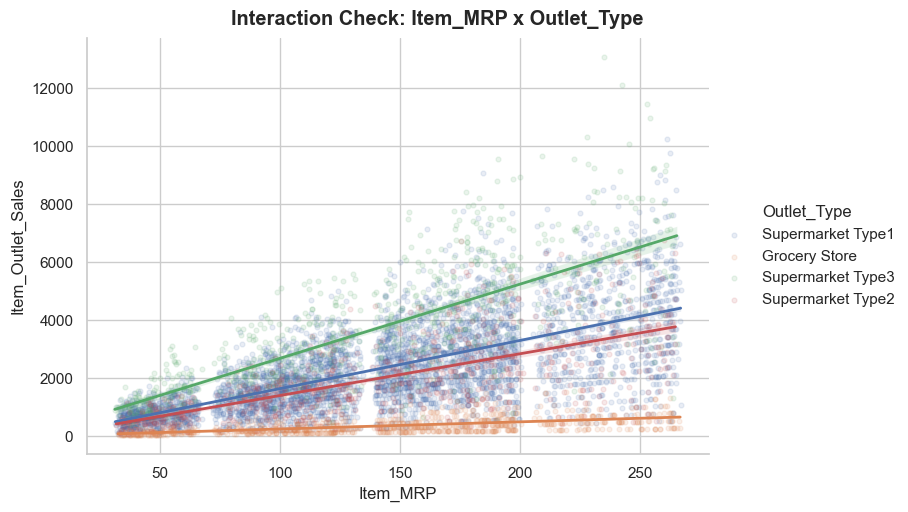

In [ ]:
# Continuous x Categorical interaction check
g = sns.lmplot(
    data=plot_df,
    x='Item_MRP',
    y='Sales_Transformed',
    hue='Outlet_Type',
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'linewidth': 2},
    height=5,
    aspect=1.5
)
g.fig.suptitle('Interaction Check: Item_MRP x Outlet_Type (Transformed)', y=1.02, fontweight='bold')
plt.show()

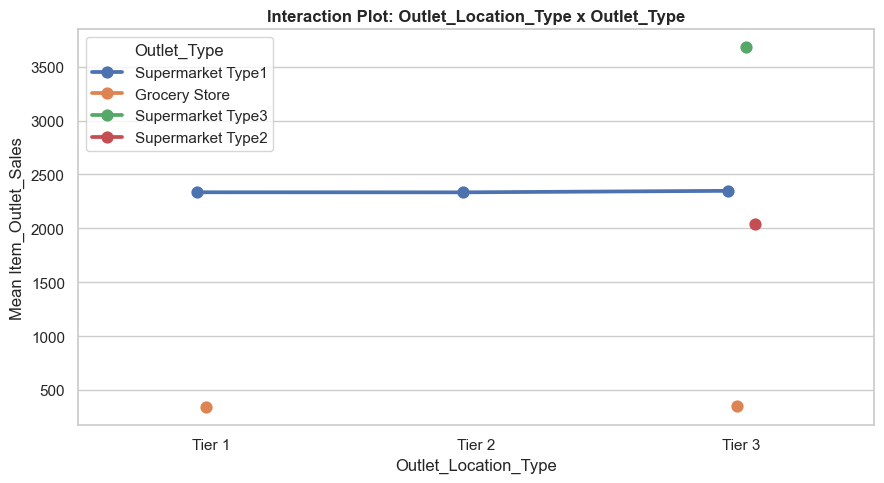

In [ ]:
# Factorial-style interaction plot: Outlet_Location_Type x Outlet_Type (Transformed)
plt.figure(figsize=(9, 5))
sns.pointplot(
    data=plot_df,
    x='Outlet_Location_Type',
    y='Sales_Transformed',
    hue='Outlet_Type',
    estimator=np.mean,
    errorbar=None,
    dodge=True
)
plt.title('Interaction Plot: Outlet_Location_Type x Outlet_Type (Transformed)', fontweight='bold')
plt.ylabel('Mean Sales_Transformed')
plt.tight_layout()
plt.show()

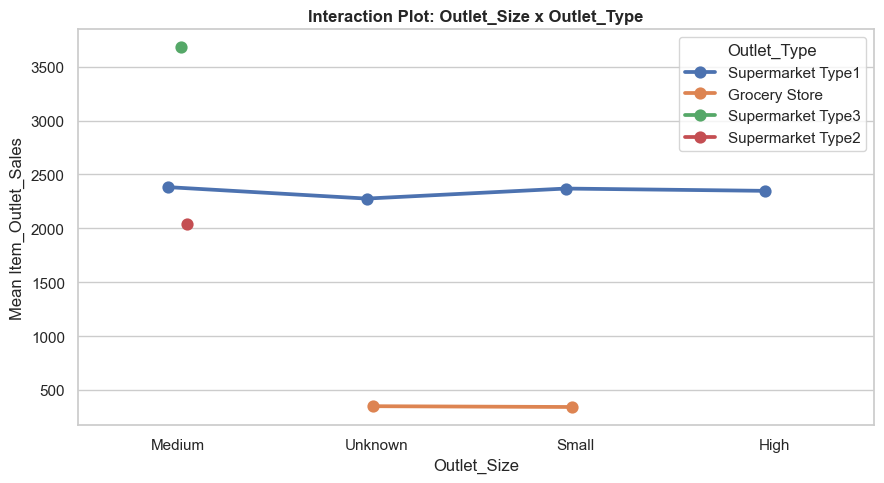

In [ ]:
# Factorial-style interaction plot: Outlet_Size x Outlet_Type (Transformed)
plt.figure(figsize=(9, 5))
sns.pointplot(
    data=plot_df,
    x='Outlet_Size',
    y='Sales_Transformed',
    hue='Outlet_Type',
    estimator=np.mean,
    errorbar=None,
    dodge=True
)
plt.title('Interaction Plot: Outlet_Size x Outlet_Type (Transformed)', fontweight='bold')
plt.ylabel('Mean Sales_Transformed')
plt.tight_layout()
plt.show()

In [ ]:
# Numeric check for non-parallel trend lines in the lmplot (Transformed Target)
print('Approximate slope of Sales_Transformed vs MRP by Outlet_Type:')
for outlet_type, grp in plot_df.groupby('Outlet_Type'):
    if grp['Item_MRP'].nunique() > 2:
        slope = np.polyfit(grp['Item_MRP'], grp['Sales_Transformed'], 1)[0]
        print(f'- {outlet_type}: {slope:.4f}')

Approximate slope of Sales vs MRP by Outlet_Type:
- Grocery Store: 2.4686
- Supermarket Type1: 16.6450
- Supermarket Type2: 14.4021
- Supermarket Type3: 25.6177


## Step 3: Apply the Marginality Principle for Hypothesis Testing
We evaluate interaction terms first (highest-order terms in this two-way model), then interpret main effects.
- Type II ANOVA is read from bottom to top.
- Partial F-tests compare the full model against reduced models that remove one interaction term at a time while retaining the associated main effects.

In [28]:
import warnings
from statsmodels.stats.anova import anova_lm
from statsmodels.tools.sm_exceptions import ValueWarning

# Type II ANOVA respects marginality (interaction terms should be judged before main effects).
with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore',
        category=ValueWarning,
        message='covariance of constraints does not have full rank'
    )
    anova_type2 = anova_lm(full_model, typ=2)

anova_type2 = anova_type2.reset_index().rename(columns={'index': 'term'})

interaction_anova = anova_type2[anova_type2['term'].str.contains(':', regex=False)].copy()
interaction_anova = interaction_anova.sort_values('PR(>F)')

print('Type II ANOVA interaction terms (smallest p-values first):')
display(interaction_anova[['term', 'sum_sq', 'df', 'F', 'PR(>F)']].head(15))

print('Read ANOVA from bottom to top (interactions before main effects):')
display(anova_type2.iloc[::-1][['term', 'sum_sq', 'df', 'F', 'PR(>F)']].head(20))

Type II ANOVA interaction terms (smallest p-values first):


,term,sum_sq,df,F,PR(>F)
32,Item_MRP:C(Outlet_Type),3.039376e+08,3.0,85.696340,2.192702e-54
30,Item_MRP:C(Outlet_Size),1.376875e+07,3.0,3.882150,8.735942e-03
9,C(Item_Type):C(Outlet_Size),7.865184e+07,45.0,1.478412,2.058024e-02
43,Item_Visibility:Outlet_Years,4.512520e+06,1.0,3.816965,5.077854e-02
26,Item_Visibility:C(Outlet_Type),6.381472e+06,3.0,1.799280,1.449912e-01
29,Item_MRP:C(Item_Type),2.242632e+07,15.0,1.264637,2.155098e-01
44,Item_MRP:Outlet_Years,1.792026e+06,1.0,1.515805,2.182996e-01
37,Outlet_Years:C(Outlet_Location_Type),3.543736e+06,2.0,1.498754,2.234848e-01
24,Item_Visibility:C(Outlet_Size),4.934162e+06,3.0,1.391205,2.434189e-01
17,Item_Weight:C(Item_Type),2.081201e+07,15.0,1.173605,2.843947e-01


Read ANOVA from bottom to top (interactions before main effects):


,term,sum_sq,df,F,PR(>F)
45,Residual,7.750682e+09,6556.0,NaN,NaN
44,Item_MRP:Outlet_Years,1.792026e+06,1.0,1.515805,2.182996e-01
43,Item_Visibility:Outlet_Years,4.512520e+06,1.0,3.816965,5.077854e-02
42,Item_Visibility:Item_MRP,1.226096e+06,1.0,1.037107,3.085328e-01
41,Item_Weight:Outlet_Years,2.956241e+05,1.0,0.250057,6.170518e-01
40,Item_Weight:Item_MRP,3.383260e+04,1.0,0.028618,8.656700e-01
39,Item_Weight:Item_Visibility,6.058211e+05,1.0,0.512440,4.741098e-01
38,Outlet_Years:C(Outlet_Type),3.667252e+06,3.0,1.033995,3.762408e-01
37,Outlet_Years:C(Outlet_Location_Type),3.543736e+06,2.0,1.498754,2.234848e-01
36,Outlet_Years:C(Outlet_Size),1.835144e+06,3.0,0.517426,6.702734e-01


In [29]:
# Partial F-tests for selected interaction terms
# Reduced model = full model without one interaction term, while keeping all lower-order terms.
def partial_f_test_interaction(term_name, full_formula, full_model, data):
    reduced_formula = f"{full_formula} - {term_name}"
    reduced_model = smf.ols(reduced_formula, data=data).fit()

    rss_full = float(np.sum(full_model.resid ** 2))
    rss_reduced = float(np.sum(reduced_model.resid ** 2))

    df_num = int(reduced_model.df_resid - full_model.df_resid)
    df_den = int(full_model.df_resid)

    f_stat = ((rss_reduced - rss_full) / df_num) / (rss_full / df_den)
    p_value = 1 - f.cdf(f_stat, df_num, df_den)

    return {
        'term': term_name,
        'rss_reduced': rss_reduced,
        'rss_full': rss_full,
        'df_num': df_num,
        'df_den': df_den,
        'F_stat': f_stat,
        'p_value': p_value
    }

# Focus on the strongest ANOVA interactions to keep runtime practical.
terms_to_test = interaction_anova['term'].head(5).tolist()

partial_results = []
for term in terms_to_test:
    try:
        partial_results.append(partial_f_test_interaction(term, full_formula, full_model, df_model))
    except Exception as err:
        partial_results.append({'term': term, 'error': str(err)})

partial_f_df = pd.DataFrame(partial_results)
print('Partial F-test results (full model vs reduced model without each interaction):')
display(partial_f_df)

Partial F-test results (full model vs reduced model without each interaction):


,term,rss_reduced,rss_full,df_num,df_den,F_stat,p_value
0,Item_MRP:C(Outlet_Type),8.054619e+09,7.750682e+09,3,6556,85.696340,0.000000
1,Item_MRP:C(Outlet_Size),7.764450e+09,7.750682e+09,3,6556,3.882150,0.008736
2,C(Item_Type):C(Outlet_Size),7.820903e+09,7.750682e+09,42,6556,1.414229,0.040184
3,Item_Visibility:Outlet_Years,7.755194e+09,7.750682e+09,1,6556,3.816965,0.050779
4,Item_Visibility:C(Outlet_Type),7.757063e+09,7.750682e+09,3,6556,1.799280,0.144991
